# 데이터 불러오기

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 26.9 MB/s eta 0:00:00


In [76]:
import koreanize_matplotlib

In [7]:
# 모든 컬럼 조회 옵션
pd.set_option('display.max_columns', None)

In [8]:
# 데이터 불러오기
customer_df = pd.read_csv("/content/customer_data.csv", sep="\t")
customer_df.head()

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,1965,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,1962,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,1973,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,1992,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,1989,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


In [6]:
customer_df.shape

(2240, 23)

In [9]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2240 non-null   int64  
 1   signup_ym              2240 non-null   object 
 2   birth_year             2240 non-null   int64  
 3   annual_income          2216 non-null   float64
 4   marital_status         2240 non-null   object 
 5   children               2240 non-null   int64  
 6   recency                2240 non-null   int64  
 7   amount_alcohol         2240 non-null   int64  
 8   amount_fruit           2240 non-null   int64  
 9   amount_meat            2240 non-null   int64  
 10  amount_fish            2240 non-null   int64  
 11  amount_snack           2240 non-null   int64  
 12  amount_general         2240 non-null   int64  
 13  num_purchase_web       2240 non-null   int64  
 14  num_purchase_store     2240 non-null   int64  
 15  num_

In [14]:
columns_object = customer_df.columns[customer_df.dtypes == 'object']
columns_object

Index(['signup_ym', 'marital_status'], dtype='object')

In [21]:
for col in columns_object:
    print(f"{col} : {customer_df[col].nunique()}개")
    print(sorted(customer_df[col].unique()))
    print()

signup_ym : 24개
['2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09']

marital_status : 4개
['미혼', '배우자 있음', '사별', '이혼']



# 데이터 전처리

## 중복값 확인

In [23]:
customer_df.duplicated().sum()

np.int64(0)

## 결측치 확인

In [24]:
customer_df.isna().sum().sum()

np.int64(24)

In [25]:
customer_df.isna().sum()

,0
ID,0
signup_ym,0
birth_year,0
annual_income,24
marital_status,0
children,0
recency,0
amount_alcohol,0
amount_fruit,0
amount_meat,0


In [27]:
customer_df.isna().mean() * 100

,0
ID,0.000000
signup_ym,0.000000
birth_year,0.000000
annual_income,1.071429
marital_status,0.000000
children,0.000000
recency,0.000000
amount_alcohol,0.000000
amount_fruit,0.000000
amount_meat,0.000000


- annual_income 컬럼의 결측치가 전체 데이터의 1% 수준이므로 결측치가 존재하는 행 삭제를 고려할 수 있다.

In [28]:
customer_df.shape

(2240, 23)

In [29]:
customer_df = customer_df.dropna()

In [30]:
customer_df.shape

(2216, 23)

In [32]:
customer_df.isna().sum()

,0
ID,0
signup_ym,0
birth_year,0
annual_income,0
marital_status,0
children,0
recency,0
amount_alcohol,0
amount_fruit,0
amount_meat,0


In [34]:
# age 컬럼
customer_df['birth_year'] = 2023 - customer_df['birth_year']

In [36]:
# 컬럼명 변경(birth_year -> age)
customer_df = customer_df.rename(columns={'birth_year' : 'age'})

In [37]:
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


## Monetary

In [39]:
data_amount_total = (customer_df['amount_alcohol']
                      + customer_df['amount_fruit']
                      + customer_df['amount_meat']
                      + customer_df['amount_fish']
                      + customer_df['amount_snack']
                      + customer_df['amount_general'])

In [42]:
index_amount_general = customer_df.columns.get_loc('amount_general')
index_amount_general

12

In [43]:
customer_df.insert(
    loc = index_amount_general + 1,
    column = 'amount_total',
    value = data_amount_total
)

In [44]:
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,0,0,0,0,0,0,11


## Frequency

In [46]:
num_purchase_total = (customer_df['num_purchase_web']
                      + customer_df['num_purchase_store']
                      + customer_df['num_purchase_discount'])

In [49]:
index_num_purchase_discount = customer_df.columns.get_loc('num_purchase_discount')
index_num_purchase_discount

16

In [50]:
customer_df.insert(
    loc = index_num_purchase_discount + 1,
    column = 'num_purchase_total',
    value = num_purchase_total
)

In [51]:
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,11


In [52]:
customer_df['revenue'].describe()

,revenue
count,2216.0
mean,11.0
std,0.0
min,11.0
25%,11.0
50%,11.0
75%,11.0
max,11.0


In [53]:
customer_df = customer_df.drop(columns=['ID', 'revenue'])

In [54]:
customer_df.head()

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
1,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
2,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
3,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
4,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


## 이상치 확인

### age

In [55]:
customer_df.describe()

,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
count,2216.000000,2.216000e+03,2216.000000,2216.000000,2.216000e+03,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,46.179603,6.792143e+07,0.947202,49.012635,3.966191e+05,34262.861011,2.170947e+05,48928.925993,35137.545126,57154.828520,7.891980e+05,4.085289,5.800993,2.323556,12.209838,0.064079,0.013538,0.073556,0.074007,0.073105,0.150271
std,11.985554,3.272500e+07,0.749062,28.948352,4.385263e+05,51732.091474,2.915683e+05,71177.707139,53393.659367,67360.038687,7.837706e+05,2.740951,3.250785,1.923716,5.861202,0.244950,0.115588,0.261106,0.261842,0.260367,0.357417
min,19.000000,2.249000e+06,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,6.500000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38.000000,4.589390e+07,0.000000,24.000000,3.120000e+04,2600.000000,2.080000e+04,3900.000000,1300.000000,11700.000000,8.970000e+04,2.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,6.679595e+07,1.000000,49.000000,2.268500e+05,10400.000000,8.840000e+04,15600.000000,10400.000000,31850.000000,5.154500e+05,4.000000,5.000000,2.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,56.000000,8.907860e+07,1.000000,74.000000,6.565000e+05,42900.000000,3.019250e+05,65000.000000,42900.000000,72800.000000,1.362400e+06,6.000000,8.000000,3.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,122.000000,8.666658e+08,3.000000,99.000000,1.940900e+06,258700.000000,2.242500e+06,336700.000000,340600.000000,417300.000000,3.282500e+06,27.000000,13.000000,15.000000,33.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [56]:
customer_df.sort_values(by='age', ascending=False)

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
239,2022-08,122,78236600.0,미혼,1,23,10400,0,6500,9100,0,2600,28600,1,2,1,4,0,0,0,0,0,0
339,2021-12,116,108591600.0,배우자 있음,0,36,981500,187200,730600,135200,83200,291200,2408900,4,4,1,9,0,0,0,0,1,0
192,2021-12,115,47632000.0,이혼,1,99,19500,7800,10400,9100,5200,32500,84500,2,2,1,5,0,0,0,0,0,0
1950,2021-10,75,66483300.0,미혼,0,96,187200,0,9100,0,0,7800,204100,3,4,1,8,0,0,0,0,0,0
424,2021-07,74,120935100.0,배우자 있음,0,77,1670500,54600,930800,71500,0,27300,2754700,7,5,0,12,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1850,2020-12,20,108234100.0,미혼,0,56,696800,35100,767000,49400,139100,87100,1774500,5,12,1,18,0,0,1,0,1,1
995,2022-06,20,45271200.0,미혼,0,65,5200,2600,14300,2600,0,5200,29900,1,2,1,4,0,0,0,0,0,0
747,2022-06,20,92511900.0,미혼,0,30,367900,22100,483600,179400,137800,57200,1248000,3,12,1,16,0,0,0,0,0,0
1170,2022-05,19,18747300.0,배우자 있음,0,81,0,0,2600,3900,3900,10400,20800,1,2,1,4,0,0,1,0,0,0


In [59]:
customer_df = customer_df[customer_df['age'] < 100]

In [60]:
customer_df.describe()

,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
count,2213.000000,2.213000e+03,2213.000000,2213.000000,2.213000e+03,2213.000000,2.213000e+03,2213.000000,2213.000000,2213.000000,2.213000e+03,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,46.082693,6.790756e+07,0.947582,49.007682,3.966997e+05,34221.192951,2.170512e+05,48925.937641,35145.232716,57084.862178,7.891282e+05,4.087664,5.805242,2.325350,12.218256,0.064166,0.013556,0.073656,0.074108,0.072752,0.150474
std,11.700216,3.273218e+07,0.749297,28.941864,4.384971e+05,51656.711025,2.914940e+05,71192.261181,53411.062876,67209.670117,7.832353e+05,2.741664,3.250752,1.924402,5.860169,0.245104,0.115666,0.261269,0.262005,0.259788,0.357617
min,19.000000,2.249000e+06,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,6.500000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38.000000,4.581980e+07,0.000000,24.000000,3.120000e+04,2600.000000,2.080000e+04,3900.000000,1300.000000,11700.000000,8.970000e+04,2.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,6.678490e+07,1.000000,49.000000,2.275000e+05,10400.000000,8.840000e+04,15600.000000,10400.000000,31200.000000,5.161000e+05,4.000000,5.000000,2.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,56.000000,8.903310e+07,1.000000,74.000000,6.565000e+05,42900.000000,3.016000e+05,65000.000000,42900.000000,72800.000000,1.362400e+06,6.000000,8.000000,3.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,75.000000,8.666658e+08,3.000000,99.000000,1.940900e+06,258700.000000,2.242500e+06,336700.000000,340600.000000,417300.000000,3.282500e+06,27.000000,13.000000,15.000000,33.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### annual_income

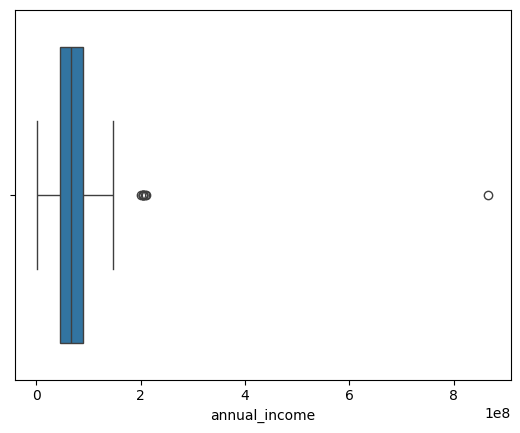

In [61]:
sns.boxplot(data=customer_df, x='annual_income')
plt.show()

In [66]:
customer_df.shape

(2213, 23)

In [68]:
# IQR 기반 이상치 처리

q3 = customer_df['annual_income'].quantile(0.75)
q1 = customer_df['annual_income'].quantile(0.25)

iqr = q3 - q1

lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr

customer_df = customer_df[(customer_df['annual_income'] >= lower_limit) & (customer_df['annual_income'] <= upper_limit)]

In [69]:
customer_df.shape

(2205, 23)

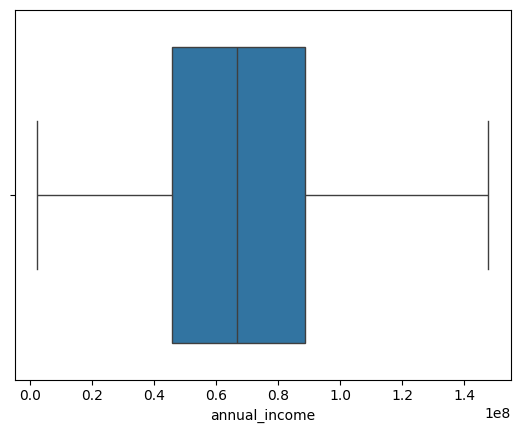

In [71]:
sns.boxplot(data=customer_df, x='annual_income')
plt.show()

# 탐색적 데이터 분석

In [72]:
customer_df.head()

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
1,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
2,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
3,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
4,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


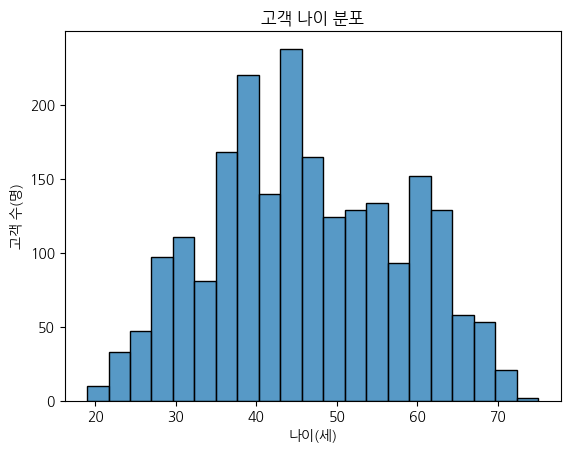

In [77]:
# 고객 나이 분포
sns.histplot(data=customer_df['age'])
plt.title("고객 나이 분포")
plt.xlabel("나이(세)")
plt.ylabel("고객 수(명)")
plt.show()

- 30대 후반에서 40대 초반 고객 수가 많은 것으로 보이고, 20대와 70대에 가까워질수록 점점 고객 수가 줄어들고 있다.

In [78]:
customer_df['age'].describe()

,age
count,2205.000000
mean,46.095692
std,11.705801
min,19.000000
25%,38.000000
50%,45.000000
75%,56.000000
max,75.000000


In [80]:
# 연령대 컬럼 추가
age_group = pd.cut(customer_df['age'],
                    bins=[10, 20, 30, 40, 50, 60, 70, 80],
                    labels=['10대', '20대', '30대', '40대', '50대', '60대', '70대'],
                    right=False)

In [83]:
index_age = customer_df.columns.get_loc('age')
index_age

1

In [84]:
customer_df.insert(
    loc = index_age + 1,
    column = 'age_group',
    value = age_group
)

In [85]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
1,2022-06,61,60대,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


In [86]:
customer_df['age_group'].value_counts()

,count
age_group,
40대,675
30대,498
50대,485
60대,337
20대,185
70대,23
10대,2


- 10대와 70대의 표본 수가 너무 적어 특정 연령대에서 표본 수가 너무 적으면, 해당 연령대에 대한 통계 수치의 신뢰성이 떨어지고 분석 결과가 왜곡되므로 10대와 20대를 20대 이하로, 60대와 70대를 60대 이상으로 바꾸겠다.

In [87]:
age_group_replace_dict = {
    '10대' : '20대 이하',
    '20대' : '20대 이하',
    '60대' : '60대 이상',
    '70대' : '60대 이상'
}

In [89]:
customer_df['age_group'] = customer_df['age_group'].replace(age_group_replace_dict)

/tmp/ipykernel_15254/2008902670.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  customer_df['age_group'] = customer_df['age_group'].replace(age_group_replace_dict)


In [90]:
customer_df['age_group'].value_counts()

,count
age_group,
40대,675
30대,498
50대,485
60대 이상,360
20대 이하,187


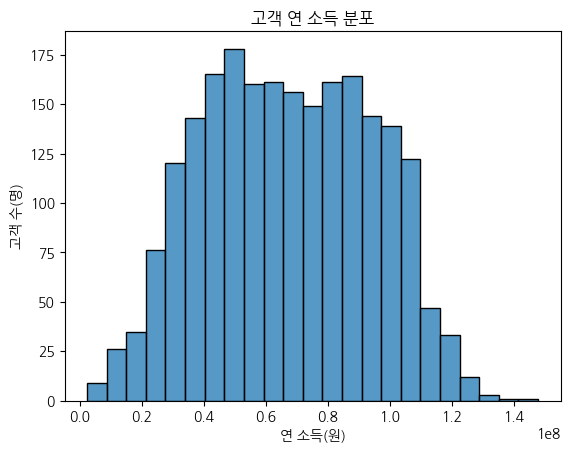

In [93]:
# 고객 연 소득 분포
sns.histplot(data=customer_df['annual_income'])
plt.title("고객 연 소득 분포")
plt.xlabel("연 소득(원)")
plt.ylabel("고객 수(명)")
plt.show()

# RFM 분석

In [95]:
num_grades = 3

grade_labels = list(range(1, num_grades + 1))
grade_labels

[1, 2, 3]

In [96]:
grade_labels[::-1]

[3, 2, 1]

## Recency

In [99]:
# Recency
customer_df['recency_grade'] = pd.qcut(x=customer_df['recency'],
                                       q=num_grades,
                                       labels=grade_labels[::-1])

In [100]:
customer_df['recency_grade'].value_counts()

,count
recency_grade,
3,752
1,730
2,723


In [104]:
groupby_recency_grade = customer_df.groupby('recency_grade').sum(numeric_only=True).reset_index()
groupby_recency_grade

/tmp/ipykernel_15254/2461487909.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_recency_grade = customer_df.groupby('recency_grade').sum(numeric_only=True).reset_index()


,recency_grade,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,3,34326,5.059218e+10,678,11988,293945600,26728000,157576900,37583000,25539800,42485300,583858600,3103,4386,1693,9182,54,12,67,55,60,179
1,2,33737,4.818995e+10,724,35840,294073000,23675600,151742500,35046700,25147200,41268500,570953500,2992,4240,1771,9003,47,8,47,52,48,95
2,1,33578,4.919261e+10,690,60237,289602300,25281100,164547500,35599200,27076400,42536000,584642500,2947,4215,1648,8810,41,10,49,57,53,59


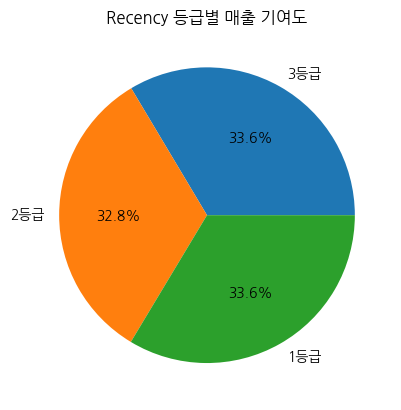

In [109]:
groupby_recency_grade['amount_total'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = [f"{x}등급" for x in grade_labels[::-1]],
    title = 'Recency 등급별 매출 기여도',
    ylabel = ''
)

plt.show()

## Frequency

In [113]:
# Frequency
customer_df['frequency_grade'] = pd.qcut(x=customer_df['num_purchase_total'],
                                       q=num_grades,
                                       labels=grade_labels)

In [114]:
customer_df['frequency_grade'].value_counts()

,count
frequency_grade,
1,851
2,679
3,675


In [115]:
groupby_frequency_grade = customer_df.groupby('frequency_grade').sum(numeric_only=True).reset_index()
groupby_frequency_grade

/tmp/ipykernel_15254/1384645853.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_frequency_grade = customer_df.groupby('frequency_grade').sum(numeric_only=True).reset_index()


,frequency_grade,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,1,36992,3.888393e+10,989,41579,55630900,7387900,38834900,10792600,7022600,17867200,137536100,1477,2560,1365,5402,7,3,61,8,7,80
1,2,31947,5.268116e+10,496,33525,342971200,32916000,220378600,47747700,33254000,50017500,727285000,2940,4021,1522,8483,69,14,54,69,87,130
2,3,32702,5.640964e+10,607,32961,479018800,35380800,214653400,49688600,37486800,58405100,874633500,4625,6260,2225,13110,66,13,48,87,67,123


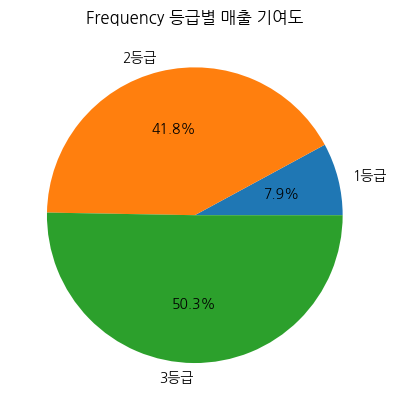

In [116]:
groupby_frequency_grade['amount_total'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = [f"{x}등급" for x in grade_labels],
    title = 'Frequency 등급별 매출 기여도',
    ylabel = ''
)

plt.show()

## Monetary

In [117]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2
1,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3


In [118]:
# Monetary
customer_df['monetary_grade'] = pd.qcut(x=customer_df['amount_total'],
                                       q=num_grades,
                                       labels=grade_labels)

In [119]:
customer_df['monetary_grade'].value_counts()

,count
monetary_grade,
1,735
2,735
3,735


In [120]:
groupby_monetary_grade = customer_df.groupby('monetary_grade').sum(numeric_only=True).reset_index()
groupby_monetary_grade

/tmp/ipykernel_15254/2757728824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_monetary_grade = customer_df.groupby('monetary_grade').sum(numeric_only=True).reset_index()


,monetary_grade,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,1,31486,2.984158e+10,944,35704,17254900,3122600,11546600,4572100,3257800,9497800,49251800,1170,2091,1307,4568,0,2,56,3,0,57
1,2,34920,4.868252e+10,814,35495,212998500,16786900,84479200,23622300,16887000,42303300,397077200,3683,4407,2365,10455,15,4,42,56,8,91
2,3,35235,6.945063e+10,334,36866,647367500,55775200,377841100,80034500,57618600,74488700,1293125600,4189,6343,1440,11972,127,24,65,105,153,185


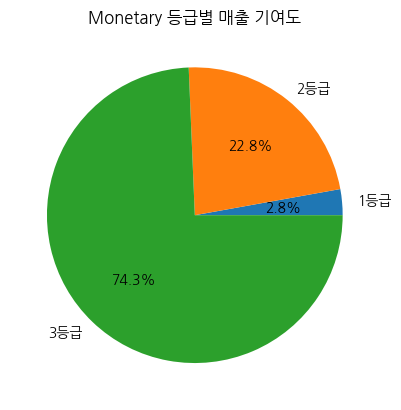

In [121]:
groupby_monetary_grade['amount_total'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = [f"{x}등급" for x in grade_labels],
    title = 'Monetary 등급별 매출 기여도',
    ylabel = ''
)

plt.show()

## RFM 모델 : 동일한 가중치

In [122]:
# 가중치
weight = {}
weight['recency'] = 1/3
weight['frequency'] = 1/3
weight['monetary'] = 1/3
weight

{'recency': 0.3333333333333333,
 'frequency': 0.3333333333333333,
 'monetary': 0.3333333333333333}

In [123]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   signup_ym              2205 non-null   object  
 1   age                    2205 non-null   int64   
 2   age_group              2205 non-null   category
 3   annual_income          2205 non-null   float64 
 4   marital_status         2205 non-null   object  
 5   children               2205 non-null   int64   
 6   recency                2205 non-null   int64   
 7   amount_alcohol         2205 non-null   int64   
 8   amount_fruit           2205 non-null   int64   
 9   amount_meat            2205 non-null   int64   
 10  amount_fish            2205 non-null   int64   
 11  amount_snack           2205 non-null   int64   
 12  amount_general         2205 non-null   int64   
 13  amount_total           2205 non-null   int64   
 14  num_purchase_web       2205 non-null   int64 

In [127]:
customer_df['rfm_score']= (
                            weight['recency'] * customer_df['recency_grade'].astype('int')
                            + weight['frequency'] * customer_df['frequency_grade'].astype('int')
                            + weight['monetary'] * customer_df['monetary_grade'].astype('int')
                            )

In [128]:
 customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.333333
1,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.333333
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.666667
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.666667
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.000000


In [129]:
customer_df['rfm_score'].describe()

,rfm_score
count,2205.000000
mean,1.976720
std,0.574077
min,1.000000
25%,1.666667
50%,2.000000
75%,2.333333
max,3.000000


rfm_score를 기반으로 rfm_segment를 구성하겠다. Recency, Frequency, Monetary Value 모두 등급이, 1, 2, 3으로 한정되어 있고, 각 가중치는 모두 더해서 1이라는 제약 조건이 있으므로 최솟값과 최댓값을 고려하여 동일한 크기의 구간으로 고객을 분류할 수 있다.

In [130]:
# rfm_segment

def rfm_segment_bins(x):
    if x < 5 / 3:
        return 1
    elif x < 7 / 3:
        return 2
    else:
        return 3

In [132]:
customer_df['rfm_segment'] = customer_df['rfm_score'].apply(rfm_segment_bins)

In [133]:
customer_df['rfm_segment'].value_counts()

,count
rfm_segment,
1,926
2,811
3,468


In [134]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').sum(numeric_only=True).reset_index()
groupby_rfm_segment

,rfm_segment,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score
0,1,40574,4.238087e+10,1119,51275,61717500,7169500,36097100,10396100,7248800,20798700,143427700,1852,2987,1709,6548,6,4,69,12,4,68,1296.000000
1,2,38632,6.346707e+10,661,44676,439615800,38247300,245863800,55347500,39518700,61659000,880252100,4193,5574,2193,11960,66,14,55,85,81,130,1773.666667
2,3,22435,4.212679e+10,312,12114,376287600,30267900,191906000,42485300,30995900,43832100,715774800,2997,4280,1210,8487,70,12,39,67,76,135,1289.000000


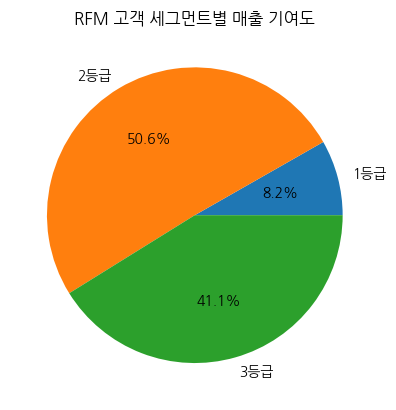

In [135]:
groupby_rfm_segment['amount_total'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = [f"{x}등급" for x in grade_labels],
    title = 'RFM 고객 세그먼트별 매출 기여도',
    ylabel = ''
)

plt.show()

## RFM 모델 : 가중치 조정

In [136]:
# 가중치 조정
weight['recency'] = 0.2
weight['frequency'] = 0.4
weight['monetary'] = 0.4

In [137]:
customer_df['rfm_score']= (
                            weight['recency'] * customer_df['recency_grade'].astype('int')
                            + weight['frequency'] * customer_df['frequency_grade'].astype('int')
                            + weight['monetary'] * customer_df['monetary_grade'].astype('int')
                            )

In [138]:
customer_df['rfm_segment'] = customer_df['rfm_score'].apply(rfm_segment_bins)

In [139]:
customer_df['rfm_segment'].value_counts()

,count
rfm_segment,
1,802
3,792
2,611


In [140]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').sum(numeric_only=True).reset_index()
groupby_rfm_segment

,rfm_segment,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score
0,1,34844,3.401424e+10,997,40993,26176800,4089800,16556800,6091800,4165200,13079300,70159700,1336,2340,1386,5062,0,2,57,5,1,60,996.6
1,2,28808,4.383286e+10,545,34358,231695100,22575800,133016000,31023200,22217000,39907400,480434500,2738,3529,1585,7852,31,6,44,48,37,78,1250.8
2,3,37989,7.012763e+10,550,32714,619749000,49019100,324294100,71113900,51381200,73303100,1188860400,4968,6972,2141,14081,111,22,62,111,123,195,2096.6


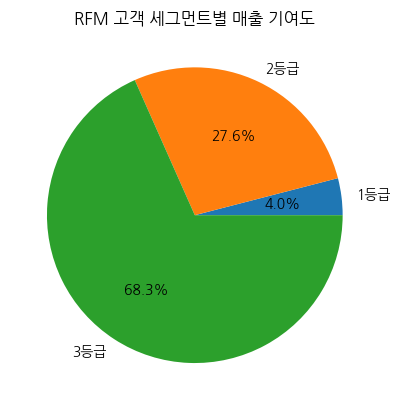

In [141]:
groupby_rfm_segment['amount_total'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = [f"{x}등급" for x in grade_labels],
    title = 'RFM 고객 세그먼트별 매출 기여도',
    ylabel = ''
)

plt.show()

# RFM 세그먼트별 특성 및 소비 성향

In [142]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.4,3
1,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.2,1
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.6,3
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.4,1
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.2,2


## 연령대별 고객 비중

In [147]:
groupby_rfm_segment_age_group = customer_df.groupby(['rfm_segment', 'age_group']).size().reset_index()
groupby_rfm_segment_age_group = groupby_rfm_segment_age_group.rename(columns={0 : 'num_customers'})
groupby_rfm_segment_age_group

/tmp/ipykernel_15254/2340842521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_rfm_segment_age_group = customer_df.groupby(['rfm_segment', 'age_group']).size().reset_index()


,rfm_segment,age_group,num_customers
0,1,20대 이하,84
1,1,30대,231
2,1,40대,268
3,1,50대,135
4,1,60대 이상,84
5,2,20대 이하,46
6,2,30대,121
7,2,40대,169
8,2,50대,161
9,2,60대 이상,114


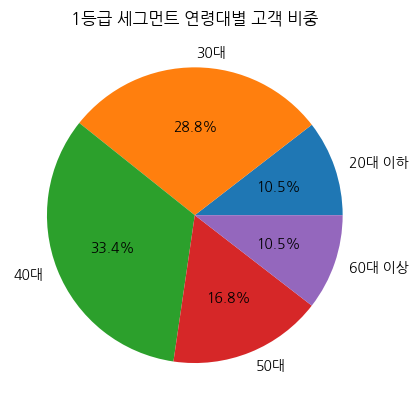

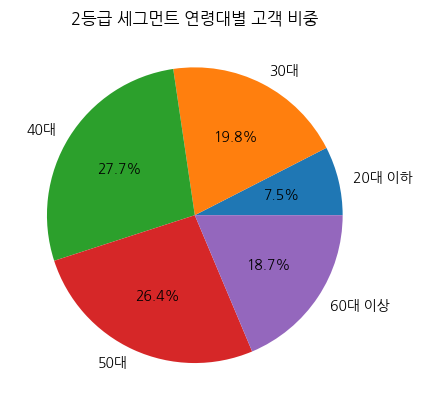

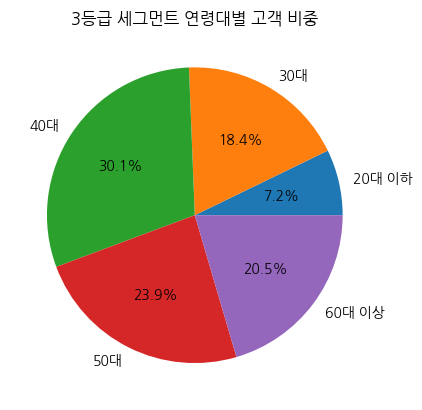

In [156]:
for i_segment in range(1, num_grades + 1):

    age_group_dist = groupby_rfm_segment_age_group[
    groupby_rfm_segment_age_group['rfm_segment'] == i_segment
    ]

    age_group_dist['num_customers'].plot(
    kind = 'pie',
    autopct = '%.1f%%',
    labels = age_group_dist['age_group'].unique(),
    title = f'{i_segment}등급 세그먼트 연령대별 고객 비중',
    ylabel = ''
    )

    plt.show()

- 매출 기여도가 높은(약 68%) 3등급 세그먼트에 집중하여 마케팅을 전개한다면, 젊은 세대보다는 중장년층을 타겟으로 하는 게 효과가 더 클 가능성이 높다.

## 품목별 매출 기여도

In [157]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.4,3
1,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.2,1
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.6,3
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.4,1
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.2,2


In [160]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').sum(numeric_only=True).reset_index()
groupby_rfm_segment

,rfm_segment,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score
0,1,34844,3.401424e+10,997,40993,26176800,4089800,16556800,6091800,4165200,13079300,70159700,1336,2340,1386,5062,0,2,57,5,1,60,996.6
1,2,28808,4.383286e+10,545,34358,231695100,22575800,133016000,31023200,22217000,39907400,480434500,2738,3529,1585,7852,31,6,44,48,37,78,1250.8
2,3,37989,7.012763e+10,550,32714,619749000,49019100,324294100,71113900,51381200,73303100,1188860400,4968,6972,2141,14081,111,22,62,111,123,195,2096.6


In [161]:
groupby_rfm_segment.columns

Index(['rfm_segment', 'age', 'annual_income', 'children', 'recency',
       'amount_alcohol', 'amount_fruit', 'amount_meat', 'amount_fish',
       'amount_snack', 'amount_general', 'amount_total', 'num_purchase_web',
       'num_purchase_store', 'num_purchase_discount', 'num_purchase_total',
       'promotion_1', 'promotion_2', 'promotion_3', 'promotion_4',
       'promotion_5', 'promotion_6', 'rfm_score'],
      dtype='object')

In [162]:
selected_columns = ['rfm_segment', 'amount_alcohol', 'amount_fruit', 'amount_meat', 'amount_fish', 'amount_snack', 'amount_general']

In [166]:
amount_sum_per_category = groupby_rfm_segment[selected_columns]
amount_sum_per_category = amount_sum_per_category.set_index('rfm_segment')
amount_sum_per_category

,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general
rfm_segment,,,,,,
1,26176800,4089800,16556800,6091800,4165200,13079300
2,231695100,22575800,133016000,31023200,22217000,39907400
3,619749000,49019100,324294100,71113900,51381200,73303100


In [171]:
amount_sum_per_category.loc[1]

,1
amount_alcohol,26176800
amount_fruit,4089800
amount_meat,16556800
amount_fish,6091800
amount_snack,4165200
amount_general,13079300


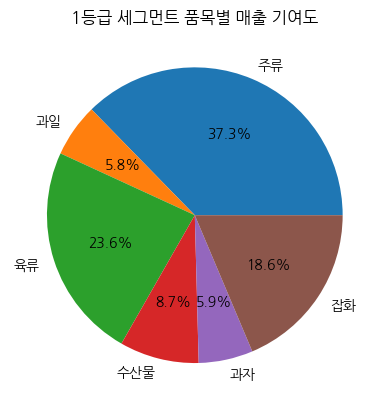

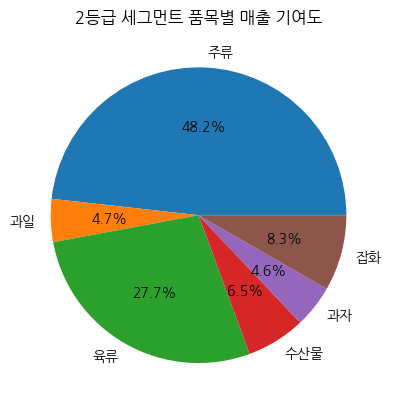

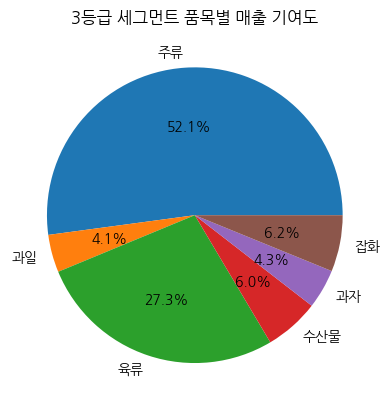

In [173]:
# RFM 세그먼트별 품목별 매출 기여도
for i_segment in range(1, num_grades + 1):
    amount_sum_per_category.loc[i_segment].plot(
        kind = 'pie',
        autopct = '%.1f%%',
        labels = ['주류', '과일', '육류', '수산물', '과자', '잡화'],
        title = f'{i_segment}등급 세그먼트 품목별 매출 기여도',
        ylabel = ''
    )

    plt.show()

- 1등급에서 3등급 세그먼트로 갈수록 주류 매출 기여도는 높고, 과일, 과자, 잡화는 매출 기여도가 줄어드는 경향을 보인다.
- 3등급은 주류 및 육류의 매출 기여도를 합치면 거의 80%에 육박함을 알 수 있다.

## 프로모션 참여율

In [174]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment
0,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.4,3
1,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.2,1
2,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.6,3
3,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.4,1
4,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.2,2


In [178]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').mean(numeric_only=True).reset_index()
groupby_rfm_segment

,rfm_segment,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score
0,1,43.446384,4.241177e+07,1.243142,51.113466,32639.401496,5099.501247,20644.389027,7595.760599,5193.516209,16308.354115,8.748092e+04,1.665835,2.917706,1.728180,6.311721,0.000000,0.002494,0.071072,0.006234,0.001247,0.074813,1.242643
1,2,47.148936,7.173954e+07,0.891980,56.232406,379206.382979,36948.936170,217702.127660,50774.468085,36361.702128,65314.893617,7.863085e+05,4.481178,5.775777,2.594108,12.851064,0.050736,0.009820,0.072013,0.078560,0.060556,0.127660,2.047136
2,3,47.965909,8.854499e+07,0.694444,41.305556,782511.363636,61892.803030,409462.247475,89790.277778,64875.252525,92554.419192,1.501086e+06,6.272727,8.803030,2.703283,17.779040,0.140152,0.027778,0.078283,0.140152,0.155303,0.246212,2.647222


In [179]:
groupby_rfm_segment.columns

Index(['rfm_segment', 'age', 'annual_income', 'children', 'recency',
       'amount_alcohol', 'amount_fruit', 'amount_meat', 'amount_fish',
       'amount_snack', 'amount_general', 'amount_total', 'num_purchase_web',
       'num_purchase_store', 'num_purchase_discount', 'num_purchase_total',
       'promotion_1', 'promotion_2', 'promotion_3', 'promotion_4',
       'promotion_5', 'promotion_6', 'rfm_score'],
      dtype='object')

In [180]:
selected_columns = ['rfm_segment', 'promotion_1', 'promotion_2', 'promotion_3', 'promotion_4', 'promotion_5', 'promotion_6']

In [183]:
avg_promotion = groupby_rfm_segment[selected_columns]
avg_promotion = avg_promotion.set_index('rfm_segment')
avg_promotion

,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
rfm_segment,,,,,,
1,0.000000,0.002494,0.071072,0.006234,0.001247,0.074813
2,0.050736,0.009820,0.072013,0.078560,0.060556,0.127660
3,0.140152,0.027778,0.078283,0.140152,0.155303,0.246212


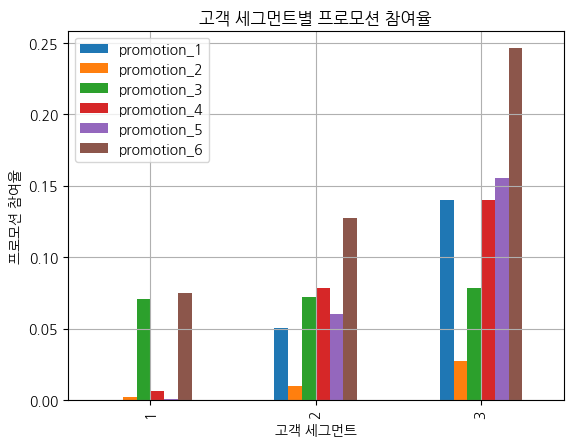

In [185]:
avg_promotion.plot(kind='bar')
plt.title('고객 세그먼트별 프로모션 참여율')
plt.xlabel('고객 세그먼트')
plt.ylabel('프로모션 참여율')
plt.grid()
plt.show()

- 고객 세그먼트 등급이 높을수록 프로모션 참여율이 전반적으로 증가함을 확인할 수 있다.
- 특히, promotion_6이 3등급 고객들에 대한 참여율이 가장 높은 것을 확인할 수 있다.